Saving Q3_Student_Dropout_Dataset.csv to Q3_Student_Dropout_Dataset.csv
Preview:
  StudentID Department  AttendancePercent  LMSLoginsPerWeek  \
0     S2001         IT               85.9              10.0   
1     S2002         IT               86.1              11.0   
2     S2003         IT              104.0               9.0   
3     S2004         AI               84.5               9.0   
4     S2005         IT               62.8               9.0   

   AssignmentAverage  FamilyIncome ScholarshipStatus DropoutRisk  
0               56.9      122686.0                No      Medium  
1               48.2       23996.0                No      Medium  
2               58.8      105651.0                No      Medium  
3               67.4      111267.0                No         Low  
4               61.6     2500000.0                No      Medium  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93 entries, 0 to 92
Data columns (total 8 columns):
 #   Column          

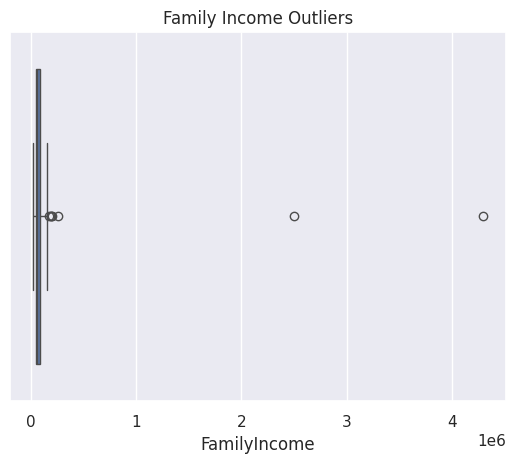


Unique values in Department:
['IT' 'AI' 'CS' 'DS' 'SE']

Unique values in DropoutRisk:
['Medium' 'Low' 'High' 'high' ' Medium' 'LOW']

Unique values in ScholarshipStatus:
['No' 'Partial' 'yes' 'Yes' ' No']

Data cleaned!


/tmp/ipykernel_7839/3923623792.py:57: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_7839/3923623792.py:59: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

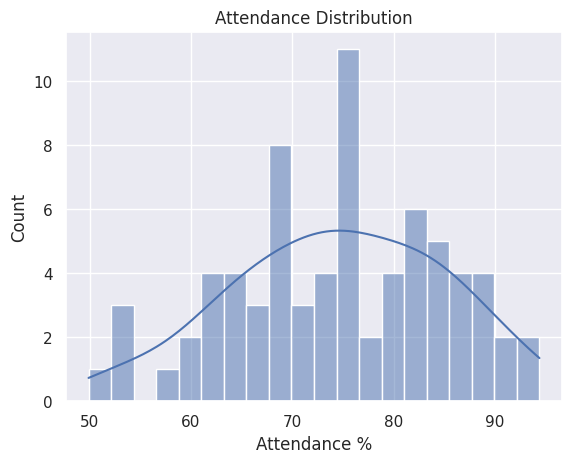

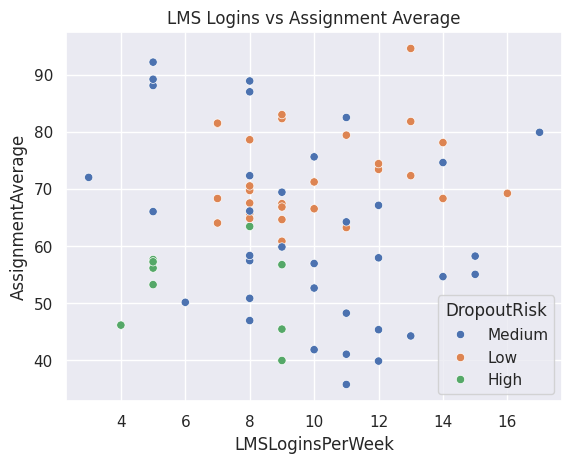

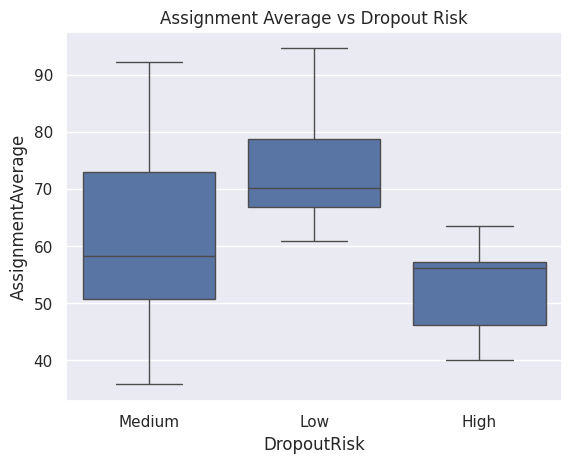


Crosstab:
DropoutRisk        High  Low  Medium
ScholarshipStatus                   
No                    2   16      24
Partial               5    7       3
Yes                   2    5       9


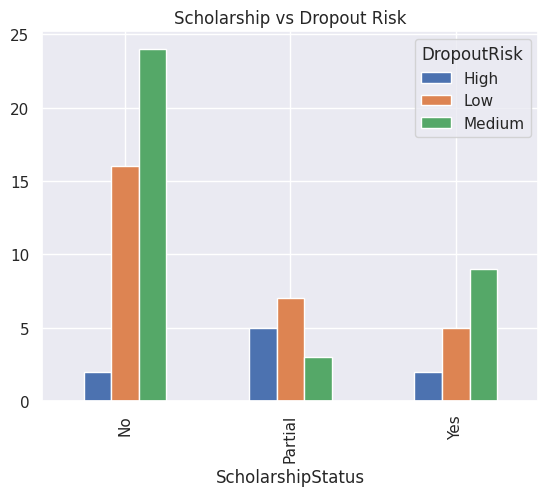


Final Data Preview:
  StudentID Department  AttendancePercent  LMSLoginsPerWeek  \
0     S2001         It               85.9              10.0   
1     S2002         It               86.1              11.0   
3     S2004         Ai               84.5               9.0   
5     S2006         Cs               80.5               5.0   
6     S2007         Ds               93.5               8.0   

   AssignmentAverage  FamilyIncome ScholarshipStatus DropoutRisk  
0               56.9      122686.0                No      Medium  
1               48.2       23996.0                No      Medium  
3               67.4      111267.0                No         Low  
5               57.6       47765.0           Partial        High  
6               46.9       32593.0           Partial      Medium  


In [1]:
# University Student Dropout Risk Study
# IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="darkgrid")

# UPLOAD DATASET
from google.colab import files
uploaded = files.upload()
df = pd.read_csv(next(iter(uploaded)))
print("Preview:")
print(df.head())

# DATASET STRUCTURE
print("\nDataset Info:")
df.info()
print("\nSummary:")
print(df.describe(include='all'))

# Identify variable types
print("\nColumn Types:")
for col in df.columns:
    if df[col].dtype == 'object':
        print(col, "-> Categorical/ID")
    else:
        print(col, "-> Numerical")

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Duplicates
print("\nDuplicate Rows:", df.duplicated().sum())

# Invalid Attendance (>100)
if 'AttendancePercent' in df.columns:
    print("\nInvalid Attendance:")
    print(df[df['AttendancePercent'] > 100])

# Extreme Income (check outliers)
if 'FamilyIncome' in df.columns:
    sns.boxplot(x=df['FamilyIncome'])
    plt.title("Family Income Outliers")
    plt.show()

# Category inconsistencies
for col in ['Department', 'DropoutRisk', 'ScholarshipStatus']:
    if col in df.columns:
        print(f"\nUnique values in {col}:")
        print(df[col].unique())

# DATA CLEANING
# Fill missing values
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].median(), inplace=True)
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Fix attendance (>100)
if 'AttendancePercent' in df.columns:
    df = df[df['AttendancePercent'] <= 100]

# Standardize categories
for col in ['Department', 'DropoutRisk', 'ScholarshipStatus']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip().str.capitalize()

# Remove extreme income outliers (IQR)
if 'FamilyIncome' in df.columns:
    Q1 = df['FamilyIncome'].quantile(0.25)
    Q3 = df['FamilyIncome'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df['FamilyIncome'] >= lower) & (df['FamilyIncome'] <= upper)]
print("\nData cleaned!")

# DISTRIBUTION PLOT (Attendance)
plt.figure()
sns.histplot(df['AttendancePercent'], bins=20, kde=True)
plt.title("Attendance Distribution")
plt.xlabel("Attendance %")
plt.show()

# SCATTER PLOT (LMS vs Assignment)
plt.figure()
sns.scatterplot(x='LMSLoginsPerWeek', y='AssignmentAverage', hue='DropoutRisk', data=df)
plt.title("LMS Logins vs Assignment Average")
plt.show()

# BOX PLOT (Assignment vs DropoutRisk)
plt.figure()
sns.boxplot(x='DropoutRisk', y='AssignmentAverage', data=df)
plt.title("Assignment Average vs Dropout Risk")
plt.show()

# CROSS TAB (Scholarship vs Dropout)
crosstab = pd.crosstab(df['ScholarshipStatus'], df['DropoutRisk'])
print("\nCrosstab:")
print(crosstab)
crosstab.plot(kind='bar')
plt.title("Scholarship vs Dropout Risk")
plt.show()

# FINAL DATA
print("\nFinal Data Preview:")
print(df.head())
